In [1]:
import sys
from pathlib import Path

import numpy as np
import scanpy as sc
from scipy import sparse

# Make project modules importable from notebooks/
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.canonical_markers import canonical_markers
from src.cluster_annotation import (
    compare_clusters_to_reference,
    score_cluster_matches,
)

In [2]:
adata = sc.read_h5ad("../data/raw/pbmc68k_reduced/pbmc68k_reduced.h5ad")
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

In [3]:
print(adata.X[:5, :5])

print(type(adata.X))

print(adata.raw)

print(adata.layers)

[[-0.326 -0.191 -0.728 -0.301  3.386]
 [ 1.171 -0.191  0.795 -1.2   -0.174]
 [-0.326 -0.191  0.483 -1.2   -0.174]
 [-0.326 -0.191  1.134 -0.157 -0.174]
 [-0.326 -0.191 -0.728 -0.607 -0.174]]
<class 'numpy.ndarray'>
Raw AnnData with n_obs × n_vars = 700 × 765
Layers with keys: None


In [4]:
raw_x = adata.raw.X

print(type(raw_x))
print("Shape:", raw_x.shape)

# check if matrix is sparse or dense, if dense use numpyarray commands
if sparse.issparse(raw_x):
    values = raw_x.data
else:
    values = np.asarray(raw_x).ravel()

print("Min stored value:", values.min())
print("Max stored value:", values.max())
print("All integer-like:", np.allclose(values, np.round(values)))
print("First 20 nonzero values:", values[:20])

<class 'scipy.sparse._csr.csr_matrix'>
Shape: (700, 765)
Min stored value: 0.719
Max stored value: 6.489
All integer-like: False
First 20 nonzero values: [2.177 2.177 2.544 2.544 1.591 1.591 1.591 1.591 1.591 1.591 1.591 1.591
 1.591 2.177 1.591 1.591 5.542 3.023 1.591 1.591]


In [5]:
adata.uns.keys()

dict_keys(['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'])

In [6]:
adata.uns["pca"]

{'variance': array([30.928047 , 21.182432 , 14.686322 , 11.570731 ,  9.232856 ,
         7.3497834,  4.338316 ,  3.197439 ,  3.1584399,  2.910167 ,
         2.649945 ,  2.540031 ,  2.4057367,  2.3872852,  2.2644212,
         2.2250588,  2.189688 ,  2.134691 ,  2.0775423,  2.0560663,
         2.007874 ,  1.9969993,  1.9606696,  1.9441428,  1.9129871,
         1.9063067,  1.8529838,  1.8260264,  1.7946786,  1.7489465,
         1.7449841,  1.7298484,  1.70099  ,  1.6571085,  1.6406441,
         1.6235017,  1.6012688,  1.5806534,  1.5531204,  1.5331998,
         1.5166894,  1.4852371,  1.4748584,  1.4530103,  1.4340347,
         1.4083625,  1.375356 ,  1.3701098,  1.356156 ,  1.3449155],
       dtype=float32),
 'variance_ratio': array([0.09770954, 0.06692067, 0.04639781, 0.03655487, 0.02916893,
        0.02321983, 0.01370584, 0.01010152, 0.00997831, 0.00919395,
        0.00837185, 0.0080246 , 0.00760033, 0.00754204, 0.00715388,
        0.00702952, 0.00691778, 0.00674403, 0.00656348, 0.0064

In [7]:
adata.uns["neighbors"]

{'params': {'method': 'umap', 'n_neighbors': array([10])}}

In [8]:
adata.uns["rank_genes_groups"]


{'names': array([('RGS19', 'ITM2A', 'CAPG', 'CCL5', 'CD8B', 'C1QA', 'CD79A', 'PRSS57', 'GNLY', 'CST3'),
        ('HIST1H4C', 'RPL39', 'GABARAPL2', 'GNLY', 'CD8A', 'PSAP', 'CD79B', 'SNHG7', 'NKG7', 'LYZ'),
        ('IL32', 'TIMM10', 'FDX1', 'NKG7', 'RP11-291B21.2', 'COX14', 'MS4A1', 'SERPINB1', 'CD7', 'LST1'),
        ('GSTK1', 'CWC15', 'CRIP1', 'GZMH', 'CD7', 'NEAT1', 'IGJ', 'C19orf77', 'CLIC3', 'IRF7'),
        ('SKP1', 'CXCR4', 'GATA3', 'CHCHD7', 'NECAP2', 'NUP214', 'IGLL5', 'SPINK2', 'SPON2', 'C10orf54'),
        ('TMBIM6', 'LSM5', 'HPCAL1', 'SRSF2', 'ANAPC16', 'RAB7A', 'SPIB', 'IMPDH2', 'TYROBP', 'ZNHIT1'),
        ('CALM3', 'LSMD1', 'DNAJC1', 'ANXA1', 'SAMD3', 'OAS1', 'UBE2J1', 'H2AFY', 'GZMB', 'CD33'),
        ('COPE', 'SUPT4H1', 'C20orf27', 'MRFAP1', 'YWHAB', 'HMGB2', 'SMARCB1', 'EGFL7', 'PLAC8', 'ILK'),
        ('CD3E', 'SRSF7', 'MIEN1', 'DUSP2', 'CARS', 'SLTM', 'MZB1', 'CYTL1', 'FCER1G', 'IL32'),
        ('CAPN2', 'MTDH', 'ACAA1', 'KLRB1', 'HMGA1', 'TMEM176B', 'CCDC50', 'SNHG8

In [9]:
adata.uns["louvain"]

{'params': {'random_state': array([0]), 'resolution': array([1])}}

In [10]:
adata = sc.read_h5ad("../data/raw/pbmc3k/pbmc3k_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [11]:

adata_raw = sc.read_h5ad("../data/raw/pbmc3k/pbmc3k_raw.h5ad")

print(adata_raw)
print(f"Shape: {adata_raw.n_obs} cells x {adata_raw.n_vars} genes")
print(f"Matrix type: {type(adata_raw.X)}")
print(f"Sparse: {sparse.issparse(adata_raw.X)}")
print(f"obs columns: {list(adata_raw.obs.columns)}")
print(f"var columns: {list(adata_raw.var.columns)}")
print(f"layers: {list(adata_raw.layers.keys())}")
print(f"raw present: {adata_raw.raw is not None}")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)
Shape: 2700 cells x 32738 genes
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparse: True
obs columns: []
var columns: ['gene_ids']
layers: [None]
raw present: False


In [12]:
# Identify mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata_raw,
    qc_vars=["mt"],
    inplace=True
)

# display first observations
adata_raw.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


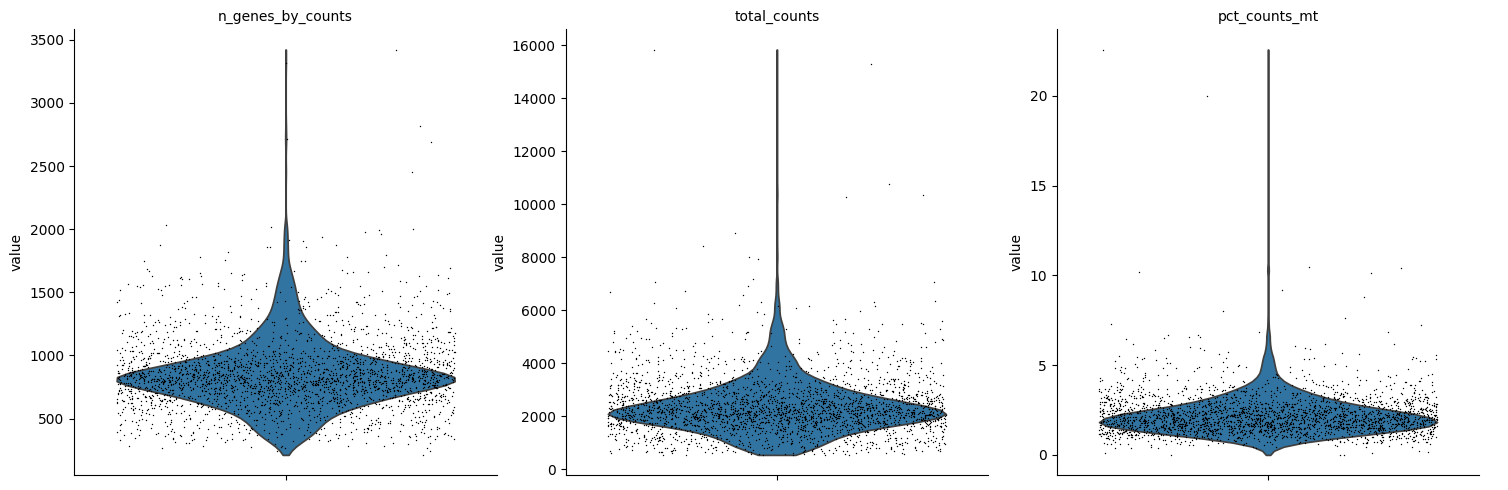

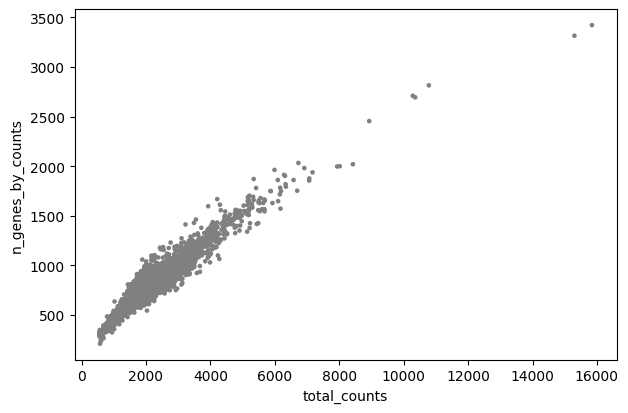

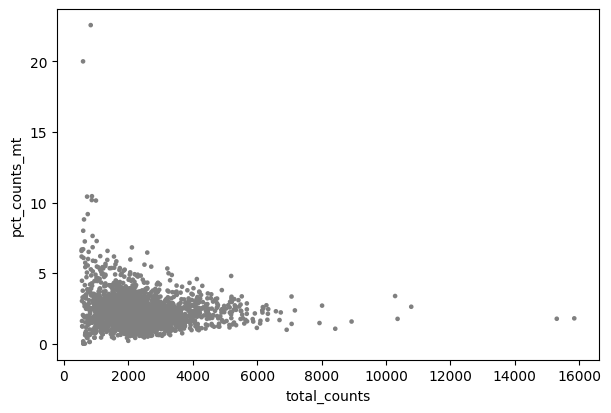

In [13]:
# Violin plots of QC metrics
sc.pl.violin(
    adata_raw,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

# Scatter plots
sc.pl.scatter(
    adata_raw,
    x="total_counts",
    y="n_genes_by_counts"
)

sc.pl.scatter(
    adata_raw,
    x="total_counts",
    y="pct_counts_mt"
)

In [14]:
adata_raw.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
    ].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


In [15]:
candidate_filters = {
    "genes_lt_200": adata_raw.obs["n_genes_by_counts"] < 200,
    "genes_lt_300": adata_raw.obs["n_genes_by_counts"] < 300,
    "genes_gt_2500": adata_raw.obs["n_genes_by_counts"] > 2500,
    "genes_gt_3000": adata_raw.obs["n_genes_by_counts"] > 3000,
    "mt_gt_5": adata_raw.obs["pct_counts_mt"] > 5,
    "mt_gt_10": adata_raw.obs["pct_counts_mt"] > 10,
}

for name, mask in candidate_filters.items():
    n_cells = mask.sum()
    pct_cells = 100 * n_cells / adata_raw.n_obs
    print(f"{name}: {n_cells} cells ({pct_cells:.2f}%)")

genes_lt_200: 0 cells (0.00%)
genes_lt_300: 15 cells (0.56%)
genes_gt_2500: 5 cells (0.19%)
genes_gt_3000: 2 cells (0.07%)
mt_gt_5: 57 cells (2.11%)
mt_gt_10: 6 cells (0.22%)


In [16]:
adata_qc = adata_raw[
    (adata_raw.obs["n_genes_by_counts"] >= 300) &
    (adata_raw.obs["pct_counts_mt"] < 5)
    ].copy()

print(f"Original cells: {adata_raw.n_obs}")
print(f"Remaining cells: {adata_qc.n_obs}")
print(f"Removed cells: {adata_raw.n_obs - adata_qc.n_obs}")
print(f"Percent removed: {(adata_raw.n_obs - adata_qc.n_obs) / adata_raw.n_obs * 100:.2f}%")

Original cells: 2700
Remaining cells: 2633
Removed cells: 67
Percent removed: 2.48%


In [17]:
gene_detection_counts = np.asarray(
    (adata_qc.X > 0).sum(axis=0)
).ravel()

for threshold in [1, 3, 5, 10]:
    removed = (gene_detection_counts < threshold).sum()
    print(
        f"min_cells={threshold}: "
        f"{removed} genes removed "
        f"({100 * removed / adata_qc.n_vars:.2f}%)"
    )

min_cells=1: 16132 genes removed (49.28%)
min_cells=3: 19046 genes removed (58.18%)
min_cells=5: 20192 genes removed (61.68%)
min_cells=10: 21620 genes removed (66.04%)


In [18]:
n_genes_before = adata_qc.n_vars

sc.pp.filter_genes(adata_qc, min_cells=3)

n_genes_after = adata_qc.n_vars

print(f"Genes before filtering: {n_genes_before}")
print(f"Genes after filtering: {n_genes_after}")
print(f"Genes removed: {n_genes_before - n_genes_after}")
print(
    f"Percent removed: "
    f"{100 * (n_genes_before - n_genes_after) / n_genes_before:.2f}%"
)

Genes before filtering: 32738
Genes after filtering: 13692
Genes removed: 19046
Percent removed: 58.18%


In [19]:
print(adata_qc)
print("Shape: ", adata_qc.shape)
print("Matrix type:", type(adata_qc.X))
print("Raw: ", adata_qc.raw)
print("Layers:", list(adata_qc.layers.keys()))

print(
    "Counts summary",
    {
        "min" : adata_qc.obs["total_counts"].min(),
        "median" : adata_qc.obs["total_counts"].median(),
        "max" : adata_qc.obs["total_counts"].max(),
    },
)

AnnData object with n_obs × n_vars = 2633 × 13692
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)
Shape:  (2633, 13692)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Raw:  None
Layers: [None]
Counts summary {'min': np.float32(561.0), 'median': np.float32(2220.0), 'max': np.float32(15844.0)}


In [20]:
adata_qc.raw = adata_qc.copy()

In [21]:
print(adata_qc.raw)

Raw AnnData with n_obs × n_vars = 2633 × 13692
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [22]:
print(adata_qc.raw is not None)
print("Raw shape:", adata_qc.raw.shape)
print("Working shape:", adata_qc.shape)

True
Raw shape: (2633, 13692)
Working shape: (2633, 13692)


In [23]:
adata_qc.layers["counts"] = adata_qc.X.copy()

In [24]:
print("Layers:", list(adata_qc.layers.keys()))
print("Counts shape:", adata_qc.layers["counts"].shape)

Layers: [None, 'counts']
Counts shape: (2633, 13692)


In [25]:
print(list(adata_qc.layers.keys()))

if None in adata_qc.layers:
    del adata_qc.layers[None]

print("Cleaned layers:", list(adata_qc.layers.keys()))

[None, 'counts']
Cleaned layers: ['counts']


In [26]:
counts = adata_qc.layers["counts"].data
print("Integer-like counts:", np.allclose(counts, np.round(counts)))

Integer-like counts: True


In [27]:
adata_qc.X = adata_qc.layers["counts"].copy()

In [28]:
print("X type:", type(adata_qc.X))
print("X shape:", adata_qc.X.shape)
print("X dtype:", adata_qc.X.dtype)
print("Layers:", list(adata_qc.layers.keys()))

X type: <class 'scipy.sparse._csr.csr_matrix'>
X shape: (2633, 13692)
X dtype: float32
Layers: ['counts', None]


In [29]:
sc.pp.normalize_total(
    adata_qc,
    target_sum=1e4
)

In [30]:
print(
    "Median total after normalization:",
    np.median(np.asarray(adata_qc.X.sum(axis=1)).ravel())
)

print(
    "Counts layer median total:",
    np.median(
        np.asarray(
            adata_qc.layers["counts"].sum(axis=1)
        ).ravel()
    )
)

Median total after normalization: 10000.0
Counts layer median total: 2218.0


In [31]:
sc.pp.log1p(adata_qc)

In [32]:
print("X min:", adata_qc.X.min())
print("X max:", adata_qc.X.max())
print(
    "Counts layer median total:",
    np.median(np.asarray(adata_qc.layers["counts"].sum(axis=1)).ravel())
)

X min: 0.0
X max: 7.4695992
Counts layer median total: 2218.0


In [33]:
adata_qc.raw = adata_qc.copy()

In [34]:
print("Raw exists:", adata_qc.raw is not None)
print("Raw shape:", adata_qc.raw.shape)
print("Working shape:", adata_qc.shape)
print("Layers:", list(adata_qc.layers.keys()))

Raw exists: True
Raw shape: (2633, 13692)
Working shape: (2633, 13692)
Layers: ['counts', None]


In [35]:
sc.pp.highly_variable_genes(
    adata_qc,
    n_top_genes=2000,
    flavor="seurat",
    subset=False
)

In [36]:
print("HVGs selected:", adata_qc.var["highly_variable"].sum())
print(adata_qc.var.columns.tolist())

HVGs selected: 2000
['gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']


In [37]:
hvg_columns = [
    col for col in
    ["highly_variable", "means", "dispersions", "dispersions_norm"]
    if col in adata_qc.var.columns
]

print(
    adata_qc.var.loc[
        adata_qc.var["highly_variable"],
        hvg_columns
    ].head(10)
)

          highly_variable     means  dispersions  dispersions_norm
index                                                             
ISG15                True  1.730835     2.903688          0.593566
TNFRSF4              True  0.273437     2.070391          0.649251
CPSF3L               True  0.386466     4.504902          2.957951
ATAD3C               True  0.038679     3.944231          4.348903
C1orf86              True  0.677007     2.712015          0.591241
RER1                 True  0.817112     3.445240          1.665282
TNFRSF25             True  0.303111     3.195505          1.282237
TNFRSF9              True  0.032205     2.691042          1.874644
CA6                  True  0.009785     2.004849          0.519847
CTNNBIP1             True  0.307804     4.212921          2.584286


In [38]:
adata_hvg = adata_qc[:, adata_qc.var["highly_variable"]].copy()

In [39]:
print(adata_hvg)
print("Shape:", adata_hvg.shape)
print("Raw shape:", adata_hvg.raw.shape)

AnnData object with n_obs × n_vars = 2633 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts', None (.X)
Shape: (2633, 2000)
Raw shape: (2633, 13692)


In [40]:
sc.pp.scale(
    adata_hvg,
    max_value=10
)

/opt/homebrew/Cellar/python@3.12/3.12.13_4/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
print("X type:", type(adata_hvg.X))
print("X shape:", adata_hvg.X.shape)
print("Mean:", np.mean(adata_hvg.X))
print("Std:", np.std(adata_hvg.X))
print("Min:", np.min(adata_hvg.X))
print("Max:", np.max(adata_hvg.X))

X type: <class 'numpy.ndarray'>
X shape: (2633, 2000)
Mean: -0.005186440534827318
Std: 0.9117698171374519
Min: -10.0
Max: 10.0


In [42]:
sc.tl.pca(
    adata_hvg,
    svd_solver="arpack"
)

In [43]:
print("PCA imbedding:", adata_hvg.obsm["X_pca"].shape)
print("PC loadings:", adata_hvg.varm["PCs"].shape)
print("Variance ratio:", adata_hvg.uns["pca"]["variance_ratio"][:10])

PCA imbedding: (2633, 50)
PC loadings: (2000, 50)
Variance ratio: [0.02568277 0.01264969 0.00880625 0.00798703 0.00537657 0.00296683
 0.00245127 0.00206243 0.00204567 0.0019481 ]


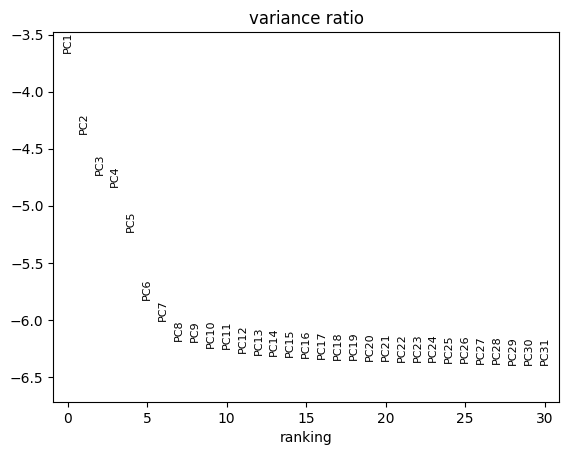

In [44]:
sc.pl.pca_variance_ratio(
    adata_hvg,
    log=True
)

In [45]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "pbmc3k_preprocessed.h5ad"

adata_hvg.write(output_path)

print(f"Saved to: {output_path.resolve()}")
print("Final shape:", adata_hvg.shape)

Saved to: /Users/Tommy/Documents/GitHub/ImmunoType/data/processed/pbmc3k_preprocessed.h5ad
Final shape: (2633, 2000)


In [46]:
adata_check = sc.read_h5ad(output_path)

print(adata_check)
print("PCA shape:", adata_check.obsm["X_pca"].shape)
print("Raw shape:", adata_check.raw.shape)
print("Counts layer:", adata_check.layers["counts"].shape)

AnnData object with n_obs × n_vars = 2633 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', None (.X)
PCA shape: (2633, 50)
Raw shape: (2633, 13692)
Counts layer: (2633, 2000)


In [47]:
# Normalized/log-transformed HVGs, before scaling
adata_ml = adata_qc[:, adata_qc.var["highly_variable"]].copy()
adata_ml.write(output_dir / "pbmc3k_hvg_log1p.h5ad")

# Scaled HVGs with PCA for exploratory analysis
adata_hvg.write(output_dir / "pbmc3k_hvg_scaled_pca.h5ad")

In [48]:
adata = sc.read_h5ad("../data/processed/pbmc3k_preprocessed.h5ad")

adata

AnnData object with n_obs × n_vars = 2633 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', None (.X)

In [49]:
print(adata)
print("Shape:", adata.shape)
print("PCA:", adata.obsm["X_pca"].shape)

AnnData object with n_obs × n_vars = 2633 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', None (.X)
Shape: (2633, 2000)
PCA: (2633, 50)


In [50]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

In [51]:
sc.tl.umap(
    adata,
    random_state=42
)

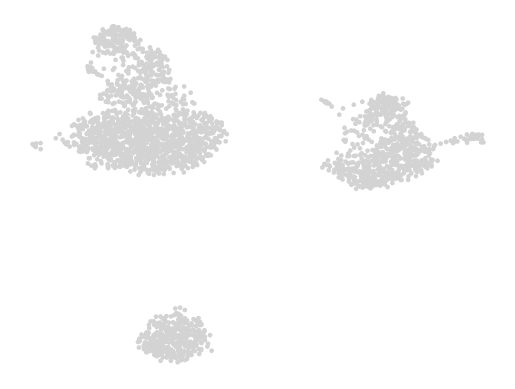

In [52]:
sc.pl.umap(
    adata,
    color=None,
    frameon=False
)

In [53]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=42,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

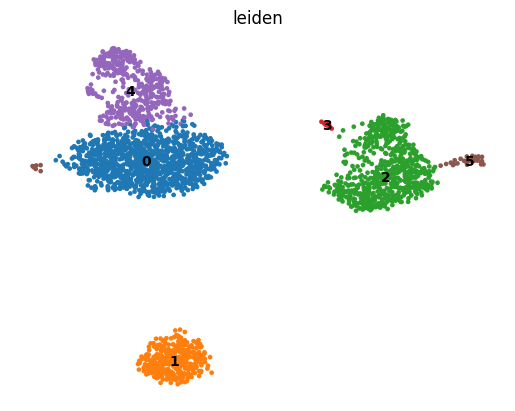

In [54]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False
)

In [55]:
print("Number of clusters:", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts().sort_index())

Number of clusters: 6
leiden
0    1175
1     342
2     639
3       9
4     425
5      43
Name: count, dtype: int64


In [56]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

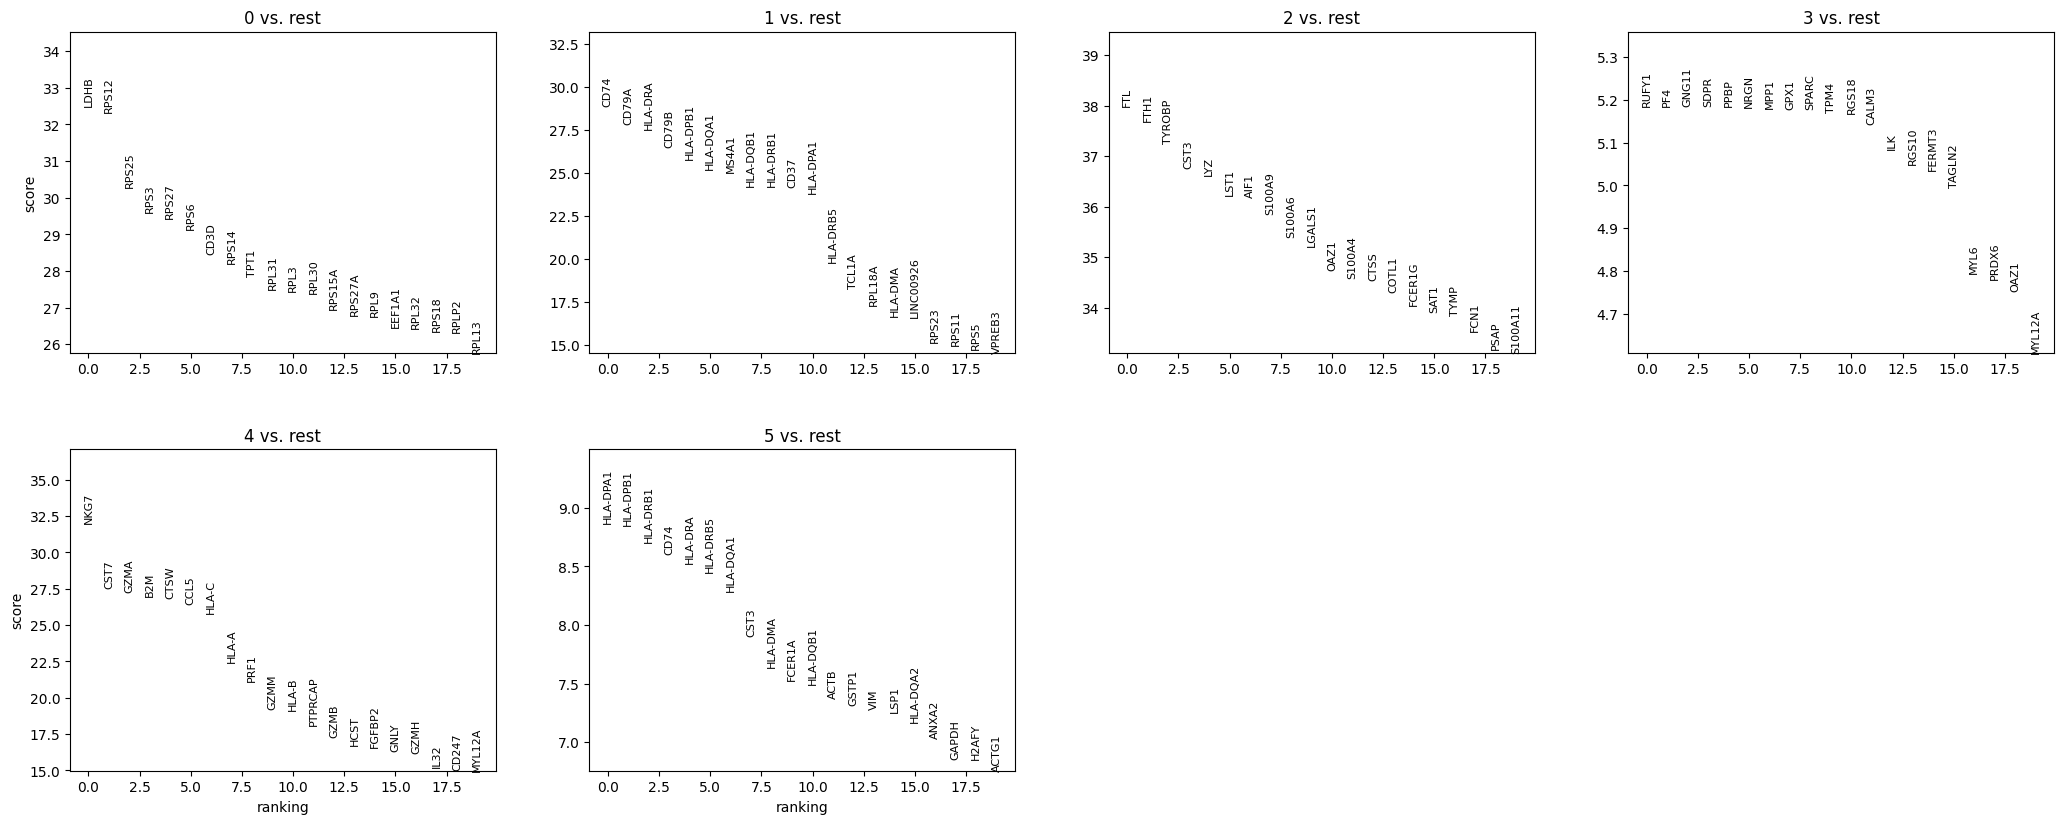

In [57]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)

In [58]:
sc.get.rank_genes_groups_df(
    adata,
    group=None
).head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.510937,2.740227,7.470074e-232,1.022803e-227
1,0,RPS12,32.328335,1.037235,2.797527e-229,1.915187e-225
2,0,RPS25,30.286449,1.164975,1.728922e-201,4.734479e-198
3,0,RPS3,29.609613,0.886206,1.123817e-192,2.198187e-189
4,0,RPS27,29.435776,1.013244,1.914757e-190,2.912984e-187
5,0,RPS6,29.135336,0.856297,1.281451e-186,1.754563e-183
6,0,CD3D,28.453754,3.276155,4.378749e-178,5.450348e-175
7,0,RPS14,28.210945,0.763961,4.292851e-175,4.521362e-172
8,0,TPT1,27.846174,0.947907,1.198405e-170,1.093904e-167
9,0,RPL31,27.491486,1.116683,2.219440e-166,1.899286e-163


In [59]:
# store clusters in dictionary
top_n = 50
cluster_markers = {}

for cluster in adata.obs["leiden"].cat.categories:
    df = sc.get.rank_genes_groups_df(
        adata,
        group=cluster
    )

    cluster_markers[str(cluster)] = (
        df["names"]
        .head(top_n)
        .tolist()
    )
cluster_markers

{'0': ['LDHB',
  'RPS12',
  'RPS25',
  'RPS3',
  'RPS27',
  'RPS6',
  'CD3D',
  'RPS14',
  'TPT1',
  'RPL31',
  'RPL3',
  'RPL30',
  'RPS15A',
  'RPS27A',
  'RPL9',
  'EEF1A1',
  'RPL32',
  'RPS18',
  'RPLP2',
  'RPL13',
  'RPS29',
  'RPL27A',
  'RPL13A',
  'RPL23A',
  'RPS3A',
  'LTB',
  'CD3E',
  'RPSA',
  'RPL21',
  'RPS4X',
  'RPS20',
  'RPL11',
  'RPS13',
  'RPL35A',
  'RPS28',
  'RPLP0',
  'RPS10',
  'IL32',
  'RPL36',
  'IL7R',
  'RPL14',
  'RPL5',
  'RPL10',
  'RPS23',
  'RPS16',
  'JUNB',
  'NPM1',
  'TMEM66',
  'MALAT1',
  'RPL10A'],
 '1': ['CD74',
  'CD79A',
  'HLA-DRA',
  'CD79B',
  'HLA-DPB1',
  'HLA-DQA1',
  'MS4A1',
  'HLA-DQB1',
  'HLA-DRB1',
  'CD37',
  'HLA-DPA1',
  'HLA-DRB5',
  'TCL1A',
  'RPL18A',
  'HLA-DMA',
  'LINC00926',
  'RPS23',
  'RPS11',
  'RPS5',
  'VPREB3',
  'HLA-DQA2',
  'HLA-DMB',
  'LTB',
  'BANK1',
  'HVCN1',
  'RPL13A',
  'CXCR4',
  'LAPTM5',
  'RPS8',
  'RPL15',
  'ISG20',
  'RPL8',
  'FCER2',
  'RPL18',
  'RPL10A',
  'SNX2',
  'RPS27',
  'LY86',


In [60]:
print(canonical_markers.keys())

dict_keys(['T_cells', 'CD4_T_cells', 'CD8_T_cells', 'Regulatory_T_cells', 'B_cells', 'Plasma_cells', 'NK_cells', 'CD14_Monocytes', 'FCGR3A_Monocytes', 'Dendritic_cells', 'Plasmacytoid_Dendritic_cells', 'Platelets', 'Megakaryocytes', 'Hematopoietic_Stem_Progenitor_Cells', 'Erythrocytes'])


In [61]:
for cell_type, info in canonical_markers.items():
    markers = (
        info["core_markers"]
        + info["supporting_markers"]
    )

    present = [
        gene for gene in markers
        if gene in adata.raw.var_names
    ]

    missing = [
        gene for gene in markers
        if gene not in adata.raw.var_names
    ]

    print(f"\n{cell_type}")
    print("Present:", present)
    print("Missing:", missing)


T_cells
Present: ['CD3D', 'CD3E', 'CD3G', 'CCR7', 'IL7R', 'LEF1', 'TCF7', 'LTB', 'GZMK']
Missing: ['TRAC']

CD4_T_cells
Present: ['CD4', 'IL7R', 'CCR7', 'LEF1', 'TCF7', 'CD40LG', 'CD3D', 'CD3E', 'GATA3']
Missing: []

CD8_T_cells
Present: ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMK', 'CCL5', 'GZMH', 'NKG7']
Missing: []

Regulatory_T_cells
Present: ['FOXP3', 'IL2RA', 'CTLA4', 'TIGIT', 'IKZF2', 'CD4', 'CCR4', 'RTKN2', 'CD3D', 'CD3E']
Missing: []

B_cells
Present: ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'CD22', 'BANK1', 'FCRLA', 'LINC00926']
Missing: ['IGHM']

Plasma_cells
Present: ['MZB1', 'TNFRSF17', 'CD38', 'DERL3', 'TXNDC5', 'PARM1']
Missing: ['JCHAIN', 'SDC1', 'IGHA1', 'IGF1']

NK_cells
Present: ['NKG7', 'GNLY', 'KLRD1', 'PRF1', 'NCAM1', 'CCL5', 'GZMB', 'GZMH', 'GZMK', 'FCGR3A', 'TYROBP', 'PTGDS']
Missing: []

CD14_Monocytes
Present: ['CD14', 'LYZ', 'S100A8', 'S100A9', 'FCN1', 'VCAN', 'CLEC4D', 'TNFAIP2', 'CCR2']
Missing: []

FCGR3A_Monocytes
Present: ['FCGR3A', 'LST1', 'MS4A7', 'AIF1

In [62]:
comparison_results = compare_clusters_to_reference(
    cluster_markers,
    canonical_markers
)

In [63]:
# Cluster comparison results
for cluster, cell_types in comparison_results.items():
    print(f"\n===== Cluster {cluster} =====")

    for cell_type, result in cell_types.items():
        if result["core_count"] > 0 or result["supporting_count"] > 0:
            print(f"\n{cell_type}")
            print("Core:", result["core_matches"])
            print("Supporting:", result["supporting_matches"])


===== Cluster 0 =====

T_cells
Core: ['CD3D', 'CD3E']
Supporting: ['IL7R', 'LTB']

CD4_T_cells
Core: ['IL7R']
Supporting: ['CD3D', 'CD3E']

CD8_T_cells
Core: []
Supporting: ['CD3D', 'CD3E']

Regulatory_T_cells
Core: []
Supporting: ['CD3D', 'CD3E']

===== Cluster 1 =====

T_cells
Core: []
Supporting: ['LTB']

B_cells
Core: ['CD79A', 'CD79B', 'MS4A1']
Supporting: ['BANK1', 'FCRLA', 'LINC00926']

Dendritic_cells
Core: []
Supporting: ['CD74', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRA']

Plasmacytoid_Dendritic_cells
Core: []
Supporting: ['HLA-DRA']

===== Cluster 2 =====

NK_cells
Core: []
Supporting: ['TYROBP']

CD14_Monocytes
Core: ['FCN1', 'LYZ', 'S100A8', 'S100A9']
Supporting: []

FCGR3A_Monocytes
Core: ['AIF1', 'LST1']
Supporting: ['FCER1G', 'IFITM3', 'LGALS3', 'SAT1', 'TYMP']

Dendritic_cells
Core: ['CST3']
Supporting: []

===== Cluster 3 =====

CD8_T_cells
Core: []
Supporting: ['CCL5']

NK_cells
Core: []
Supporting: ['CCL5']

Platelets
Core: ['GNG11', 'PF4', 'PPBP', 'RGS18']
Supporting: ['GP

In [64]:
# weighted scoring
comparison_results = compare_clusters_to_reference(
    cluster_markers,
    canonical_markers
)

scored_results = score_cluster_matches(
    comparison_results,
    canonical_markers
)

In [66]:
for cluster, cell_types, in scored_results.items():
    print(f"\n===== Cluster {cluster} =====")

    ranked = sorted(
        cell_types.items(),
        key=lambda x: x[1]["normalized_score"],
        reverse=True
    )
    for cell_type, result in ranked[:5]:
        print(
            f"{cell_type:35s} "
            f"score={result['normalized_score']:.3f} "
            f"core={result['core_matches']} "
            f"supporting={result['supporting_matches']}"
        )


===== Cluster 0 =====
T_cells                             score=0.429 core=['CD3D', 'CD3E'] supporting=['IL7R', 'LTB']
CD4_T_cells                         score=0.267 core=['IL7R'] supporting=['CD3D', 'CD3E']
CD8_T_cells                         score=0.200 core=[] supporting=['CD3D', 'CD3E']
Regulatory_T_cells                  score=0.133 core=[] supporting=['CD3D', 'CD3E']
B_cells                             score=0.000 core=[] supporting=[]

===== Cluster 1 =====
B_cells                             score=0.562 core=['CD79A', 'CD79B', 'MS4A1'] supporting=['BANK1', 'FCRLA', 'LINC00926']
Dendritic_cells                     score=0.333 core=[] supporting=['CD74', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRA']
T_cells                             score=0.071 core=[] supporting=['LTB']
Plasmacytoid_Dendritic_cells        score=0.071 core=[] supporting=['HLA-DRA']
CD4_T_cells                         score=0.000 core=[] supporting=[]

===== Cluster 2 =====
FCGR3A_Monocytes                    score=0.692

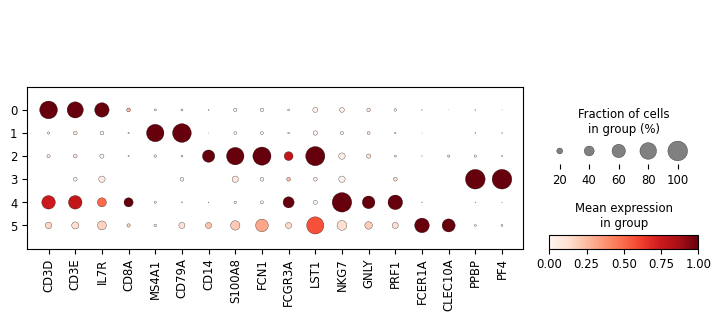

In [67]:
validation_markers = [
    # T cells
    "CD3D", "CD3E", "IL7R", "CD8A",

    # B cells
    "MS4A1", "CD79A",

    # Monocytes
    "CD14", "S100A8", "FCN1", "FCGR3A", "LST1",

    # NK cells
    "NKG7", "GNLY", "PRF1",

    # Dendritic cells
    "FCER1A", "CLEC10A",

    # Platelets
    "PPBP", "PF4"
]

sc.pl.dotplot(
    adata,
    validation_markers,
    groupby="leiden",
    use_raw=True,
    standard_scale="var"
)

In [68]:
cluster_annotations = {
    "0": "CD4 T cells",
    "1": "B cells",
    "2": "CD14 Monocytes",
    "3": "Platelets",
    "4": "NK cells",
    "5": "Dendritic cells",
}

In [69]:
adata.obs["cell_type"] = (
    adata.obs["leiden"]
    .astype(str)
    .map(cluster_annotations)
)

In [70]:
print(
    adata.obs[["leiden", "cell_type"]]
    .value_counts()
    .sort_index()
)

leiden  cell_type      
0       B cells               0
        CD14 Monocytes        0
        CD4 T cells        1175
        Dendritic cells       0
        NK cells              0
        Platelets             0
1       B cells             342
        CD14 Monocytes        0
        CD4 T cells           0
        Dendritic cells       0
        NK cells              0
        Platelets             0
2       B cells               0
        CD14 Monocytes      639
        CD4 T cells           0
        Dendritic cells       0
        NK cells              0
        Platelets             0
3       B cells               0
        CD14 Monocytes        0
        CD4 T cells           0
        Dendritic cells       0
        NK cells              0
        Platelets             9
4       B cells               0
        CD14 Monocytes        0
        CD4 T cells           0
        Dendritic cells       0
        NK cells            425
        Platelets             0
5       B cells 

In [71]:
output_path = (
    project_root
    / "data"
    / "processed"
    / "pbmc3k_clustered_annotated.h5ad"
)

adata.write(output_path)

print(f"Saved to: {output_path}")

Saved to: /Users/Tommy/Documents/GitHub/ImmunoType/data/processed/pbmc3k_clustered_annotated.h5ad


In [72]:
print(adata.obs["cell_type"].value_counts())
print(adata.obs[["leiden", "cell_type"]].drop_duplicates().sort_values("leiden"))

cell_type
CD4 T cells        1175
CD14 Monocytes      639
NK cells            425
B cells             342
Dendritic cells      43
Platelets             9
Name: count, dtype: int64
                 leiden        cell_type
index                                   
AAACATACAACCAC-1      0      CD4 T cells
AAACATTGAGCTAC-1      1          B cells
AAACCGTGCTTCCG-1      2   CD14 Monocytes
ACCCACTGGTTCAG-1      3        Platelets
AAACCGTGTATGCG-1      4         NK cells
AAGATTACCGCCTT-1      5  Dendritic cells


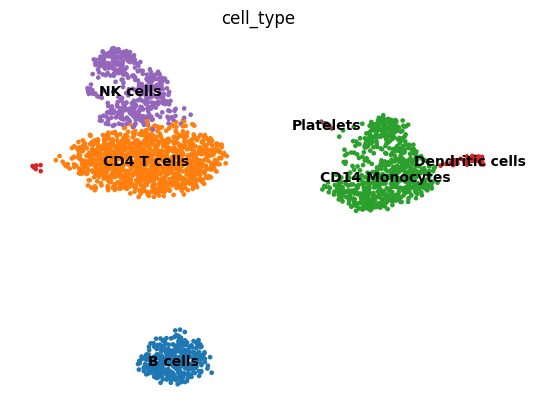

In [73]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    frameon=False
)